# Linear Regression Single-Trajectory Estimation: SGD vs Full-Batch GD

This notebook studies the Appendix B coupled setting on a single SGD-vs-GD trajectory model class, but now **averages the resulting traces over five independent seeds**. For each seed, the notebook generates one linear-regression problem, one matched full-batch GD trajectory, and one SGD trajectory on the same dataset.

For the stored SGD states `\hat\theta_t`, define the observed and predictable Appendix B targets

- `b_t = \eta^{-1}(\hat\theta_t - \hat\theta_{t+1}) - \eta^{-1}(\theta_t - \theta_{t+1})`
- `b_t^* = \nabla L(\hat\theta_t) - \nabla L(\theta_t)`

Restrict the model class to the scalar ridge family `R_\lambda(\theta) = (\lambda/2) \|\theta\|_2^2`, so `\nabla R_\lambda(\theta) = \lambda \theta`. The notebook then:

1. runs the coupled SGD/GD experiment for five seeds,
2. estimates the empirical and oracle scalar ridge coefficients from progressively longer trajectory prefixes,
3. plots the seed-averaged ridge estimates against timestep with 95% standard-error bands, and
4. plots the empirical and oracle Appendix B losses side by side, again with 95% standard-error bands.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

ROOT = Path.cwd()
if not (ROOT / "figures").exists() and (ROOT.parent / "figures").exists():
    ROOT = ROOT.parent

FIG_DIR = ROOT / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

style_path = ROOT / "clean_fig.mplstyle"
if style_path.exists():
    plt.style.use(style_path)


In [2]:
def mse_grad(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    return X.T @ (X @ theta - y) / n


def mse_grad_trajectory(X: torch.Tensor, y: torch.Tensor, thetas: torch.Tensor) -> torch.Tensor:
    n = X.shape[0]
    c = (X.T @ y) / n
    A = (X.T @ X) / n
    return thetas @ A.T - c.unsqueeze(0)


def batch_grad(X: torch.Tensor, y: torch.Tensor, theta: torch.Tensor, idx: torch.Tensor) -> torch.Tensor:
    Xb = X[idx]
    yb = y[idx]
    n = Xb.shape[0]
    return Xb.T @ (Xb @ theta - yb) / n


def gd_trajectory(X: torch.Tensor, y: torch.Tensor, steps: int, lr: float) -> torch.Tensor:
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    for _ in range(steps):
        theta = theta - lr * mse_grad(X, y, theta)
        thetas.append(theta.clone())
    return torch.stack(thetas)


def sgd_trajectory(
    X: torch.Tensor,
    y: torch.Tensor,
    steps: int,
    lr: float,
    batch_size: int,
    generator: torch.Generator,
) -> torch.Tensor:
    theta = torch.zeros(X.shape[1], dtype=X.dtype)
    thetas = [theta.clone()]
    n = X.shape[0]
    for _ in range(steps):
        idx = torch.randint(n, (batch_size,), generator=generator)
        theta = theta - lr * batch_grad(X, y, theta, idx)
        thetas.append(theta.clone())
    return torch.stack(thetas)


def fit_scalar_ridge_from_points(theta_points: torch.Tensor, target_points: torch.Tensor) -> torch.Tensor:
    numer = (theta_points * target_points).sum()
    denom = theta_points.square().sum().clamp_min(1e-12)
    return numer / denom


def fit_scalar_ridge_from_trajectory(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    steps_used: int,
    burn_in: int = 0,
) -> torch.Tensor:
    if steps_used <= burn_in:
        raise ValueError("steps_used must be greater than burn_in")
    return fit_scalar_ridge_from_points(theta_points[burn_in:steps_used], target_points[burn_in:steps_used])


def appendix_b_loss(
    theta_points: torch.Tensor,
    target_points: torch.Tensor,
    lam,
    burn_in: int = 0,
    steps_used = None,
    average: bool = True,
) -> float:
    end = theta_points.shape[0] if steps_used is None else steps_used
    if end <= burn_in:
        raise ValueError("steps_used must be greater than burn_in")
    lam_tensor = torch.as_tensor(lam, dtype=theta_points.dtype, device=theta_points.device)
    residual = target_points[burn_in:end] - lam_tensor * theta_points[burn_in:end]
    per_step_sq_norm = residual.square().sum(dim=1)
    return per_step_sq_norm.mean().item() if average else per_step_sq_norm.sum().item()


def mean_and_se95(values: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    mean = values.mean(dim=0)
    if values.shape[0] == 1:
        se95 = torch.zeros_like(mean)
    else:
        se95 = 1.96 * values.std(dim=0, unbiased=True) / (values.shape[0] ** 0.5)
    return mean, se95


def plot_trace_with_se(
    ax: plt.Axes,
    x: np.ndarray,
    mean: np.ndarray,
    se95: np.ndarray,
    title: str,
    xlabel: str,
    ylabel: str,
    color: str,
    label: str,
    linestyle: str = "-",
    logy: bool = False,
    alpha: float = 0.22,
):
    plot_mean = np.maximum(mean, 1e-12) if logy else mean
    lower = mean - se95
    upper = mean + se95
    if logy:
        lower = np.maximum(lower, 1e-12)
        upper = np.maximum(upper, 1e-12)
        ax.set_yscale("log")
    ax.plot(x, plot_mean, color=color, linewidth=2.0, label=label, linestyle=linestyle)
    ax.fill_between(x, lower, upper, color=color, alpha=alpha, linewidth=0)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(alpha=0.3, which="both")


def run_seed(seed: int, p: int, n: int, steps: int, lr: float, batch_size: int, burn_in: int):
    data_generator = torch.Generator().manual_seed(seed)
    X = torch.randn(n, p, generator=data_generator)
    beta = 3.0 * torch.randn(p, generator=data_generator)
    y = X @ beta

    theta_gd = gd_trajectory(X, y, steps, lr)
    full_grad_gd = mse_grad_trajectory(X, y, theta_gd)

    sgd_generator = torch.Generator().manual_seed(seed + 100)
    theta_sgd = sgd_trajectory(X, y, steps, lr, batch_size, sgd_generator)
    theta_points = theta_sgd[:-1]
    b_obs = (theta_sgd[:-1] - theta_sgd[1:]) / lr - (theta_gd[:-1] - theta_gd[1:]) / lr
    b_star = mse_grad_trajectory(X, y, theta_points) - full_grad_gd[:-1]

    retained_steps = torch.arange(burn_in + 1, steps + 1)
    lambda_empirical_trace = torch.empty(len(retained_steps), dtype=X.dtype)
    lambda_oracle_trace = torch.empty(len(retained_steps), dtype=X.dtype)
    empirical_loss_empirical_fit = torch.empty(len(retained_steps), dtype=X.dtype)
    empirical_loss_oracle_fit = torch.empty(len(retained_steps), dtype=X.dtype)
    oracle_loss_empirical_fit = torch.empty(len(retained_steps), dtype=X.dtype)
    oracle_loss_oracle_fit = torch.empty(len(retained_steps), dtype=X.dtype)

    for i, steps_used in enumerate(retained_steps.tolist()):
        lam_hat = fit_scalar_ridge_from_trajectory(theta_points, b_obs, steps_used, burn_in=burn_in)
        lam_star = fit_scalar_ridge_from_trajectory(theta_points, b_star, steps_used, burn_in=burn_in)
        lambda_empirical_trace[i] = lam_hat
        lambda_oracle_trace[i] = lam_star
        empirical_loss_empirical_fit[i] = appendix_b_loss(theta_points, b_obs, lam_hat, burn_in=burn_in, steps_used=steps_used, average=True)
        empirical_loss_oracle_fit[i] = appendix_b_loss(theta_points, b_obs, lam_star, burn_in=burn_in, steps_used=steps_used, average=True)
        oracle_loss_empirical_fit[i] = appendix_b_loss(theta_points, b_star, lam_hat, burn_in=burn_in, steps_used=steps_used, average=True)
        oracle_loss_oracle_fit[i] = appendix_b_loss(theta_points, b_star, lam_star, burn_in=burn_in, steps_used=steps_used, average=True)

    return {
        "trajectory_gap_norm": torch.linalg.norm(theta_sgd - theta_gd, dim=1),
        "observed_target_norm": torch.linalg.norm(b_obs, dim=1),
        "predictable_target_norm": torch.linalg.norm(b_star, dim=1),
        "lambda_empirical_trace": lambda_empirical_trace,
        "lambda_oracle_trace": lambda_oracle_trace,
        "empirical_loss_empirical_fit": empirical_loss_empirical_fit,
        "empirical_loss_oracle_fit": empirical_loss_oracle_fit,
        "oracle_loss_empirical_fit": oracle_loss_empirical_fit,
        "oracle_loss_oracle_fit": oracle_loss_oracle_fit,
    }


In [3]:
BASE_SEED = 56
NUM_SEEDS = 10
SEEDS = [BASE_SEED + offset for offset in range(NUM_SEEDS)]
P = 10
N = 1000
LR = 1e-2
STEPS = 1000
BATCH_SIZE = 8
BURN_IN = 50


torch.use_deterministic_algorithms(False)

seed_runs = [run_seed(seed, P, N, STEPS, LR, BATCH_SIZE, BURN_IN) for seed in SEEDS]
retained_steps = torch.arange(BURN_IN + 1, STEPS + 1)
steps = torch.arange(STEPS + 1)
traj_steps = torch.arange(1, STEPS + 1)

trajectory_gap_norm = torch.stack([run["trajectory_gap_norm"] for run in seed_runs])
observed_target_norm = torch.stack([run["observed_target_norm"] for run in seed_runs])
predictable_target_norm = torch.stack([run["predictable_target_norm"] for run in seed_runs])
lambda_empirical_trace = torch.stack([run["lambda_empirical_trace"] for run in seed_runs])
lambda_oracle_trace = torch.stack([run["lambda_oracle_trace"] for run in seed_runs])
empirical_loss_empirical_fit = torch.stack([run["empirical_loss_empirical_fit"] for run in seed_runs])
empirical_loss_oracle_fit = torch.stack([run["empirical_loss_oracle_fit"] for run in seed_runs])
oracle_loss_empirical_fit = torch.stack([run["oracle_loss_empirical_fit"] for run in seed_runs])
oracle_loss_oracle_fit = torch.stack([run["oracle_loss_oracle_fit"] for run in seed_runs])

trajectory_gap_mean, trajectory_gap_se95 = mean_and_se95(trajectory_gap_norm)
observed_target_mean, observed_target_se95 = mean_and_se95(observed_target_norm)
predictable_target_mean, predictable_target_se95 = mean_and_se95(predictable_target_norm)
lambda_empirical_mean, lambda_empirical_se95 = mean_and_se95(lambda_empirical_trace)
lambda_oracle_mean, lambda_oracle_se95 = mean_and_se95(lambda_oracle_trace)
empirical_loss_empirical_mean, empirical_loss_empirical_se95 = mean_and_se95(empirical_loss_empirical_fit)
empirical_loss_oracle_mean, empirical_loss_oracle_se95 = mean_and_se95(empirical_loss_oracle_fit)
oracle_loss_empirical_mean, oracle_loss_empirical_se95 = mean_and_se95(oracle_loss_empirical_fit)
oracle_loss_oracle_mean, oracle_loss_oracle_se95 = mean_and_se95(oracle_loss_oracle_fit)

print(f"Seeds: {SEEDS}")
print(f"Burn-in: {BURN_IN} steps")
print(
    "Final empirical scalar ridge estimate: "
    f"{lambda_empirical_mean[-1].item():.6f} +/- {lambda_empirical_se95[-1].item():.6f}"
)
print(
    "Final oracle scalar ridge estimate: "
    f"{lambda_oracle_mean[-1].item():.6f} +/- {lambda_oracle_se95[-1].item():.6f}"
)
print(
    "Final empirical-fit empirical loss: "
    f"{empirical_loss_empirical_mean[-1].item():.6f} +/- {empirical_loss_empirical_se95[-1].item():.6f}"
)
print(
    "Final oracle-fit oracle loss: "
    f"{oracle_loss_oracle_mean[-1].item():.6f} +/- {oracle_loss_oracle_se95[-1].item():.6f}"
)


Seeds: [56, 57, 58, 59, 60, 61, 62, 63, 64, 65]
Burn-in: 50 steps
Final empirical scalar ridge estimate: 0.000591 +/- 0.001501
Final oracle scalar ridge estimate: 0.000781 +/- 0.002373
Final empirical-fit empirical loss: 2.304326 +/- 0.757479
Final oracle-fit oracle loss: 0.024333 +/- 0.005739


## 1) Coupled SGD-vs-GD trajectory averaged over five seeds

The first figure averages the SGD-vs-GD trajectory diagnostics over the five seeds and shows 95% standard-error bands around each mean trace.


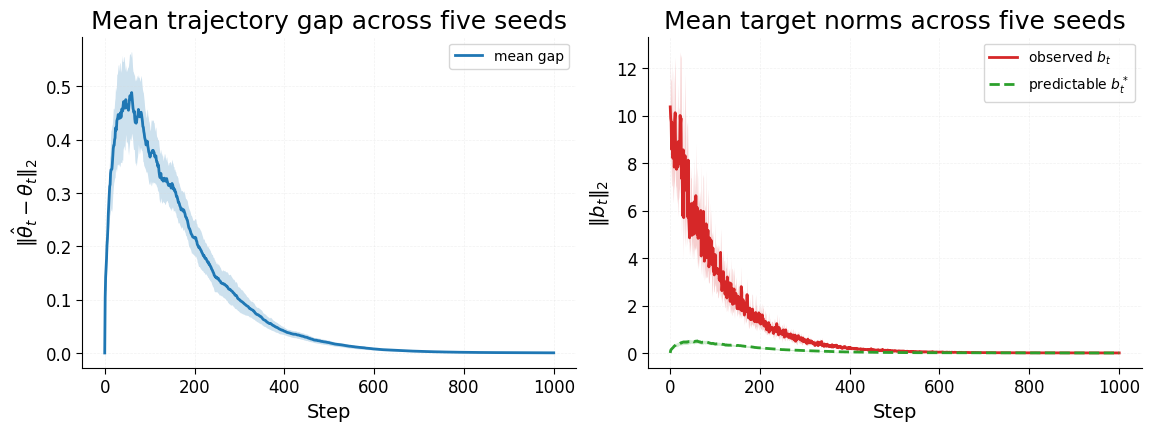

linear_regression_sgd_vs_gd_trajectory_gap.pdf


In [4]:
fig_gap_path = FIG_DIR / "linear_regression_sgd_vs_gd_trajectory_gap.pdf"
fig, axes = plt.subplots(1, 2, figsize=(11.4, 4.2), constrained_layout=True)

plot_trace_with_se(
    axes[0],
    steps.numpy(),
    trajectory_gap_mean.numpy(),
    trajectory_gap_se95.numpy(),
    title="Mean trajectory gap across five seeds",
    xlabel="Step",
    ylabel=r"$\|\hat{\theta}_t - \theta_t\|_2$",
    color="#1f77b4",
    label="mean gap",
)
axes[0].legend()

plot_trace_with_se(
    axes[1],
    traj_steps.numpy(),
    observed_target_mean.numpy(),
    observed_target_se95.numpy(),
    title="Mean target norms across five seeds",
    xlabel="Step",
    ylabel=r"$\|b_t\|_2$",
    color="#d62728",
    label="observed $b_t$",
)
plot_trace_with_se(
    axes[1],
    traj_steps.numpy(),
    predictable_target_mean.numpy(),
    predictable_target_se95.numpy(),
    title="Mean target norms across five seeds",
    xlabel="Step",
    ylabel=r"$\|b_t\|_2$",
    color="#2ca02c",
    label="predictable $b_t^*$",
    linestyle="--",
)
axes[1].legend()

fig.savefig(fig_gap_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(fig_gap_path.name)


## 2) Scalar ridge estimate against timestep

For each seed and each retained prefix `m = BURN_IN + 1, \ldots, T`, fit

- `\hat\lambda_m` from the observed targets `b_t`
- `\lambda_m^*` from the predictable targets `b_t^*`

The next plot shows the five-seed mean ridge estimates with 95% standard-error bands.


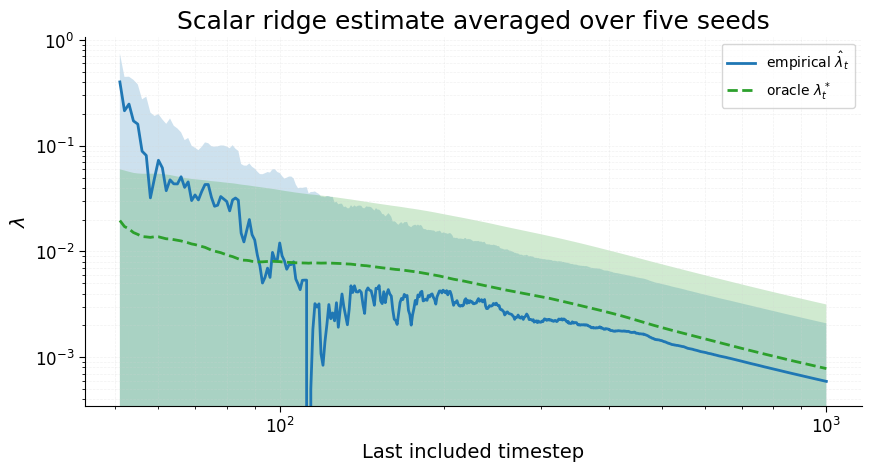

empirical scalar ridge estimate at timestep 51: 0.400891 +/- 0.344234
empirical scalar ridge estimate at timestep 1000: 0.000591 +/- 0.001501
oracle scalar ridge estimate at timestep 51: 0.019613 +/- 0.040290
oracle scalar ridge estimate at timestep 1000: 0.000781 +/- 0.002373
linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf


In [8]:
fig_lambda_path = FIG_DIR / "linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf"
fig, ax = plt.subplots(figsize=(8.6, 4.6), constrained_layout=True)

plot_trace_with_se(
    ax,
    retained_steps.numpy(),
    lambda_empirical_mean.numpy(),
    lambda_empirical_se95.numpy(),
    title="Scalar ridge estimate averaged over five seeds",
    xlabel="Last included timestep",
    ylabel=r"$\lambda$",
    color="#1f77b4",
    label=r"empirical $\hat{\lambda}_t$",
)
plot_trace_with_se(
    ax,
    retained_steps.numpy(),
    lambda_oracle_mean.numpy(),
    lambda_oracle_se95.numpy(),
    title="Scalar ridge estimate averaged over five seeds",
    xlabel="Last included timestep",
    ylabel=r"$\lambda$",
    color="#2ca02c",
    label=r"oracle $\lambda_t^*$",
    linestyle="--",
)
ax.legend()
plt.yscale('log')
plt.xscale('log')
fig.savefig(fig_lambda_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(
    f"empirical scalar ridge estimate at timestep {retained_steps[0].item()}: "
    f"{lambda_empirical_mean[0].item():.6f} +/- {lambda_empirical_se95[0].item():.6f}"
)
print(
    f"empirical scalar ridge estimate at timestep {retained_steps[-1].item()}: "
    f"{lambda_empirical_mean[-1].item():.6f} +/- {lambda_empirical_se95[-1].item():.6f}"
)
print(
    f"oracle scalar ridge estimate at timestep {retained_steps[0].item()}: "
    f"{lambda_oracle_mean[0].item():.6f} +/- {lambda_oracle_se95[0].item():.6f}"
)
print(
    f"oracle scalar ridge estimate at timestep {retained_steps[-1].item()}: "
    f"{lambda_oracle_mean[-1].item():.6f} +/- {lambda_oracle_se95[-1].item():.6f}"
)
print(fig_lambda_path.name)


## 3) Empirical and oracle losses

The Appendix B losses are averaged over the same five seeds and shown side by side with 95% standard-error bands.

To keep prefixes comparable, the plotted values are **per-step averages** rather than raw sums:

- left: empirical loss `\hat E_m(\lambda)/(m-BURN_IN)`
- right: oracle loss `E_m(\lambda)/(m-BURN_IN)`

Each panel compares the empirical-fit scalar `\hat\lambda_m` against the oracle-fit scalar `\lambda_m^*`.


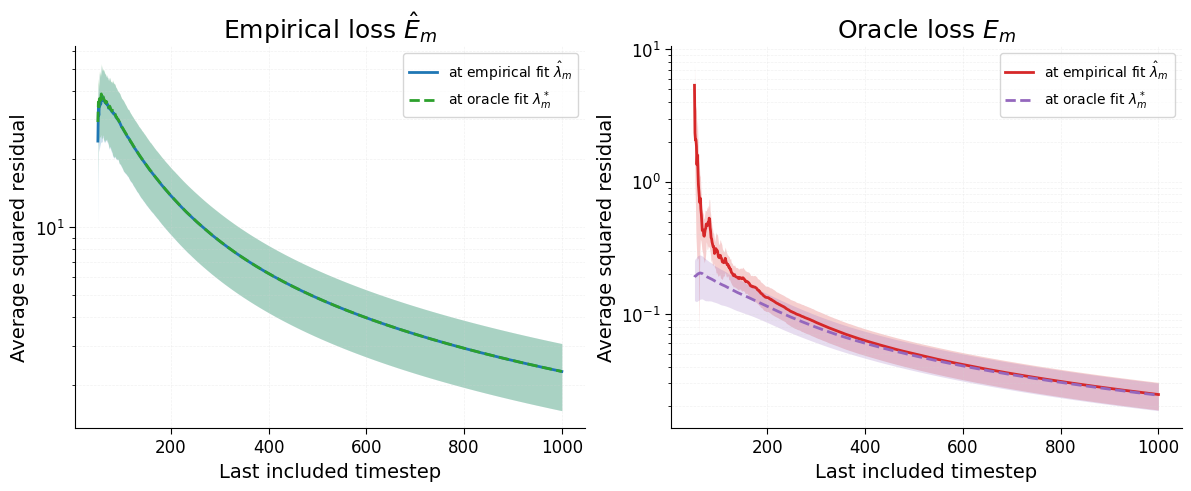

final empirical loss at empirical fit: 2.304326 +/- 0.757479
final empirical loss at oracle fit: 2.304619 +/- 0.757596
final oracle loss at empirical fit: 0.024626 +/- 0.005804
final oracle loss at oracle fit: 0.024333 +/- 0.005739
linear_regression_sgd_vs_gd_ridge_losses.pdf


In [6]:
fig_loss_path = FIG_DIR / "linear_regression_sgd_vs_gd_ridge_losses.pdf"
fig, axes = plt.subplots(1, 2, figsize=(11.8, 4.8), constrained_layout=True)

plot_trace_with_se(
    axes[0],
    retained_steps.numpy(),
    empirical_loss_empirical_mean.numpy(),
    empirical_loss_empirical_se95.numpy(),
    title=r"Empirical loss $\hat{E}_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#1f77b4",
    label=r"at empirical fit $\hat{\lambda}_m$",
    logy=True,
)
plot_trace_with_se(
    axes[0],
    retained_steps.numpy(),
    empirical_loss_oracle_mean.numpy(),
    empirical_loss_oracle_se95.numpy(),
    title=r"Empirical loss $\hat{E}_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#2ca02c",
    label=r"at oracle fit $\lambda_m^*$",
    linestyle="--",
    logy=True,
)
axes[0].legend()

plot_trace_with_se(
    axes[1],
    retained_steps.numpy(),
    oracle_loss_empirical_mean.numpy(),
    oracle_loss_empirical_se95.numpy(),
    title=r"Oracle loss $E_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#d62728",
    label=r"at empirical fit $\hat{\lambda}_m$",
    logy=True,
)
plot_trace_with_se(
    axes[1],
    retained_steps.numpy(),
    oracle_loss_oracle_mean.numpy(),
    oracle_loss_oracle_se95.numpy(),
    title=r"Oracle loss $E_m$",
    xlabel="Last included timestep",
    ylabel="Average squared residual",
    color="#9467bd",
    label=r"at oracle fit $\lambda_m^*$",
    linestyle="--",
    logy=True,
)
axes[1].legend()

fig.savefig(fig_loss_path, bbox_inches="tight")
display(fig)
plt.close(fig)

print(
    "final empirical loss at empirical fit: "
    f"{empirical_loss_empirical_mean[-1].item():.6f} +/- {empirical_loss_empirical_se95[-1].item():.6f}"
)
print(
    "final empirical loss at oracle fit: "
    f"{empirical_loss_oracle_mean[-1].item():.6f} +/- {empirical_loss_oracle_se95[-1].item():.6f}"
)
print(
    "final oracle loss at empirical fit: "
    f"{oracle_loss_empirical_mean[-1].item():.6f} +/- {oracle_loss_empirical_se95[-1].item():.6f}"
)
print(
    "final oracle loss at oracle fit: "
    f"{oracle_loss_oracle_mean[-1].item():.6f} +/- {oracle_loss_oracle_se95[-1].item():.6f}"
)
print(fig_loss_path.name)


In [7]:
print(fig_gap_path)
print(fig_lambda_path)
print(fig_loss_path)


/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_trajectory_gap.pdf
/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_ridge_lambda_trace.pdf
/home/kevin/OneDrive/Documents/UMich/Research/inductive-bias/figures/linear_regression_sgd_vs_gd_ridge_losses.pdf
